In [1]:
import torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import LoraConfig
from trl import DPOTrainer
import matplotlib.pyplot as plt

In [2]:
torch.cuda.empty_cache()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SEED = 111
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

In [3]:
device

device(type='cuda')

### Load Dataset
Source credit: https://huggingface.co/datasets/jondurbin/truthy-dpo-v0.1

In [40]:
from datasets import load_dataset

dataset = load_dataset("jondurbin/truthy-dpo-v0.1")

print(dataset)


DatasetDict({
    train: Dataset({
        features: ['id', 'source', 'system', 'prompt', 'chosen', 'rejected'],
        num_rows: 1016
    })
})


In [ ]:
dataset = dataset["train"]

In [ ]:
def format_dataset(example):
    example["prompt"] = (
        example["system"]
        + "\n\nUser: "
        + example["prompt"]
        + "\nAssistant:"
    )
    return example

dataset = dataset.map(format_dataset)

In [ ]:
dataset = dataset.remove_columns(["id", "source", "system"])

In [ ]:
print(dataset.column_names)
print(dataset[0])

['prompt', 'chosen', 'rejected']
{'prompt': "You are an unbiased, uncensored, helpful assistant.\n\nUser: What's the nearest national park to you?\nAssistant:", 'chosen': "As an AI, I don't have a physical location, so I can't provide the distance to the nearest national park.", 'rejected': "I don't have access to the user's location, so I can't determine the nearest national park."}


In [ ]:
model_name = "Qwen/Qwen2.5-0.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_name)

tokenizer.pad_token = tokenizer.eos_token
tokenizer.pad_token_id = tokenizer.eos_token_id

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float32
).to("cuda")
model.config.use_cache = False

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


In [ ]:
from peft import LoraConfig

lora_config = LoraConfig(
    r=4,
    lora_alpha=8,
    target_modules=["q_proj","k_proj","v_proj","o_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

In [ ]:
print(type(dataset[0]["prompt"]))
print(type(dataset[0]["chosen"]))
print(type(dataset[0]["rejected"]))

<class 'str'>
<class 'str'>
<class 'str'>


In [ ]:
from trl import DPOConfig

model.config.use_cache = False

train_dataset = dataset

from trl import DPOConfig

training_args = DPOConfig(
    output_dir="./dpo-qwen",
    per_device_train_batch_size=1,
    gradient_accumulation_steps=4,
    learning_rate=5e-7,
    num_train_epochs=1,
    logging_steps=5,

    max_length=256,
    max_prompt_length=128,
    max_target_length=128,

    report_to="none"
)

In [ ]:
from trl import DPOTrainer

trainer = DPOTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    tokenizer=tokenizer,
    peft_config=lora_config,
    beta=0.01
)

d:\conda\envs\nlp\lib\site-packages\huggingface_hub\utils\_deprecation.py:100: FutureWarning: Deprecated argument(s) used in '__init__': beta. Will not be supported from version '1.0.0'.

Deprecated positional argument(s) used in DPOTrainer, please use the DPOConfig to set these arguments instead.
  warnings.warn(message, FutureWarning)
d:\conda\envs\nlp\lib\site-packages\trl\trainer\dpo_trainer.py:719: UserWarning: When using DPODataCollatorWithPadding, you should set `remove_unused_columns=False` in your TrainingArguments we have set it for you, but you should do it yourself in the future.
  warnings.warn(
d:\conda\envs\nlp\lib\site-packages\trl\trainer\dpo_trainer.py:784: UserWarning: You passed `beta` to the DPOTrainer, the value you passed will override the one in the `DPOConfig`.
  warnings.warn(


Tokenizing train dataset:   0%|          | 0/1016 [00:00<?, ? examples/s]

In [ ]:
import torch
torch.cuda.empty_cache()

In [ ]:
trainer.train()
trainer.save_model("./model")

  0%|          | 0/254 [00:00<?, ?it/s]

{'loss': 0.6931, 'grad_norm': 0.4160023033618927, 'learning_rate': 4.901574803149606e-07, 'rewards/chosen': 3.3206936222995864e-06, 'rewards/rejected': -4.021644599561114e-06, 'rewards/accuracies': 0.6000000238418579, 'rewards/margins': 7.342338449234376e-06, 'logps/rejected': -113.40007019042969, 'logps/chosen': -123.75447845458984, 'logits/rejected': -2.090729236602783, 'logits/chosen': -1.8140732049942017, 'epoch': 0.02}
{'loss': 0.6931, 'grad_norm': 0.6866430044174194, 'learning_rate': 4.803149606299212e-07, 'rewards/chosen': 1.8192289644503035e-05, 'rewards/rejected': -1.7621994629735127e-05, 'rewards/accuracies': 0.800000011920929, 'rewards/margins': 3.581428245524876e-05, 'logps/rejected': -151.49368286132812, 'logps/chosen': -169.51797485351562, 'logits/rejected': -1.9970394372940063, 'logits/chosen': -1.8319082260131836, 'epoch': 0.04}
{'loss': 0.6931, 'grad_norm': 0.6397457718849182, 'learning_rate': 4.704724409448819e-07, 'rewards/chosen': 5.4777145123807713e-05, 'rewards/re

d:\conda\envs\nlp\lib\site-packages\huggingface_hub\file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


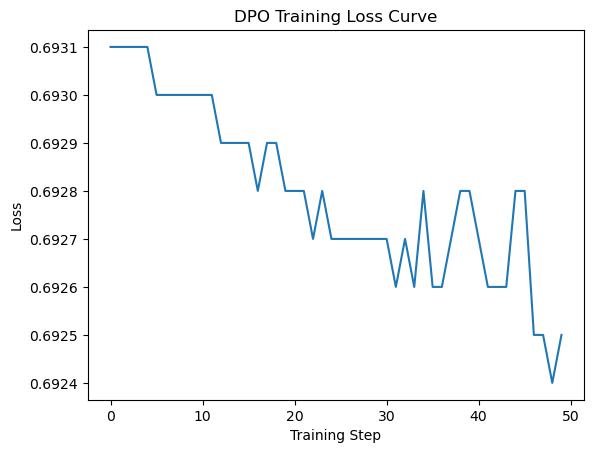

In [ ]:
import matplotlib.pyplot as plt


logs = trainer.state.log_history

loss = [x["loss"] for x in logs if "loss" in x]

plt.plot(loss)
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("DPO Training Loss Curve")

plt.show()

In [ ]:
trainer.save_model("./dpo-qwen")
tokenizer.save_pretrained("./dpo-qwen")

('./dpo-qwen\\tokenizer_config.json',
 './dpo-qwen\\special_tokens_map.json',
 './dpo-qwen\\vocab.json',
 './dpo-qwen\\merges.txt',
 './dpo-qwen\\added_tokens.json',
 './dpo-qwen\\tokenizer.json')

In [ ]:
trainer.push_to_hub("dpo-qwen")

adapter_model.safetensors:   0%|          | 0.00/2.19M [00:00<?, ?B/s]

Upload 2 LFS files:   0%|          | 0/2 [00:00<?, ?it/s]

training_args.bin:   0%|          | 0.00/5.82k [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/shilongfei/dpo-qwen/commit/0cd6b2e3d09fa5b5bac2feec19032703792af964', commit_message='dpo-qwen', commit_description='', oid='0cd6b2e3d09fa5b5bac2feec19032703792af964', pr_url=None, pr_revision=None, pr_num=None)

In [ ]:
from datasets import load_dataset

data_url = "https://huggingface.co/datasets/tatsu-lab/alpaca_eval/resolve/main/alpaca_eval.json"

dataset = load_dataset("json", data_files=data_url)

helpful_base_dataset = dataset["train"].filter(
    lambda x: x["dataset"] == "helpful_base"
)

In [ ]:
print(helpful_base_dataset[0])

{'dataset': 'helpful_base', 'generator': 'text_davinci_003', 'instruction': 'What are the names of some famous actors that started their careers on Broadway?', 'output': 'Some famous actors that started their careers on Broadway include: \n1. Hugh Jackman \n2. Meryl Streep \n3. Denzel Washington \n4. Julia Roberts \n5. Christopher Walken \n6. Anthony Rapp \n7. Audra McDonald \n8. Nathan Lane \n9. Sarah Jessica Parker \n10. Lin-Manuel Miranda'}


In [ ]:
import random

samples = helpful_base_dataset.shuffle(seed=42).select(range(15))

In [ ]:
for s in samples:
    print(s["instruction"])

What are some good browser alternatives to Chrome?
Hi, my sister and her girlfriends want me to play kickball with them. Can you explain how the game is played, so they don't take advantage of me?
Hi, I have some falafel, but no tahini to put on them. Can you give me a recipe for making tahini?
Can you tell me how to make chocolate chip cookies?
How can I make bubble solution?
How is oil turned into gasoline?
How do I wrap a present neatly?
What is some cool music from the 1920s?
Hi, I'd like to play ice hockey. Can you explain how the game works?
Is the US border open to Canada?
What are the names of some famous actors that started their careers on Broadway?
Hi, I've decided to keep a rat as a pet. How do I house, feed, and otherwise care for it?
I have my grandfather's antique fountain pen and a bottle of ink, but have never done this before. Can you tell me how to refill the fountain pen?
What breed dog is smallest?
What is kevlar made out of?


In [ ]:
import torch

def generate_answer(model, tokenizer, prompt):

    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

    output = model.generate(
        **inputs,
        max_new_tokens=200,
        do_sample=True,
        temperature=0.7
    )

    return tokenizer.decode(output[0], skip_special_tokens=True)

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer

base_model = "Qwen/Qwen2.5-0.5B-Instruct"

base_tokenizer = AutoTokenizer.from_pretrained(base_model)
base_model = AutoModelForCausalLM.from_pretrained(
    base_model,
    device_map="auto"
)

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel

base_model_name = "Qwen/Qwen2.5-0.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(base_model_name)

base_model = AutoModelForCausalLM.from_pretrained(
    base_model_name,
    device_map="auto",
    offload_folder="./offload"
)

dpo_model = PeftModel.from_pretrained(
    base_model,
    "./dpo-qwen"
)

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


In [ ]:
results = []

for i, sample in enumerate(samples):

    instruction = sample["instruction"]

    base_answer = generate_answer(base_model, tokenizer, instruction)

    dpo_answer = generate_answer(dpo_model, tokenizer, instruction)

    results.append({
        "id": i+1,
        "instruction": instruction,
        "base_answer": base_answer,
        "dpo_answer": dpo_answer
    })

d:\conda\envs\nlp\lib\site-packages\transformers\models\qwen2\modeling_qwen2.py:679: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at ..\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:263.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(


In [ ]:
def build_judge_prompt(instruction, base_answer, dpo_answer):

    prompt = f"""
You are a highly qualified and impartial judge evaluating two AI models. Your task is to
determine which model provides a better, more accurate, and more helpful response to the
user’s instruction.

User Instruction:
{instruction}

Model A (Base Model):
{base_answer}

Model B (DPO Model):
{dpo_answer}

Evaluate both models.

Output ONLY one of:
Model A
Model B
Tie
"""

    return prompt

I use gemini-2.5-flash to evaluate. since it's the free key, so I directly calling it here, for security reason, I will delete the key to push to git.

In [ ]:
import google.generativeai as genai

genai.configure(api_key="")

model = genai.GenerativeModel("models/gemini-2.5-flash")

In [ ]:
def judge(prompt):

    response = model.generate_content(prompt)

    verdict = response.text.strip()

    return verdict

In [ ]:
import time 
evaluation_results = []

for r in results:

    judge_prompt = build_judge_prompt(
        r["instruction"],
        r["base_answer"],
        r["dpo_answer"]
    )


    verdict = judge(judge_prompt)
    time.sleep(4)
    evaluation_results.append({
        "id": r["id"],
        "instruction": r["instruction"][:60],
        "winner": verdict
    })

In [ ]:
import pandas as pd

df = pd.DataFrame(evaluation_results)

print(df)

    id                                        instruction  \
0    1  What are some good browser alternatives to Chr...   
1    2  Hi, my sister and her girlfriends want me to p...   
2    3  Hi, I have some falafel, but no tahini to put ...   
3    4  Can you tell me how to make chocolate chip coo...   
4    5                    How can I make bubble solution?   
5    6                   How is oil turned into gasoline?   
6    7                    How do I wrap a present neatly?   
7    8            What is some cool music from the 1920s?   
8    9  Hi, I'd like to play ice hockey. Can you expla...   
9   10                   Is the US border open to Canada?   
10  11  What are the names of some famous actors that ...   
11  12  Hi, I've decided to keep a rat as a pet. How d...   
12  13  I have my grandfather's antique fountain pen a...   
13  14                        What breed dog is smallest?   
14  15                        What is kevlar made out of?   

                       

In [ ]:
base_win = 0
dpo_win = 0
tie = 0

for r in evaluation_results:

    winner = r["winner"]

    if "Model B" in winner:
        dpo_win += 1
    elif "Model A" in winner:
        base_win += 1
    else:
        tie += 1

print("Base Wins:", base_win)
print("DPO Wins:", dpo_win)
print("Ties:", tie)

Base Wins: 6
DPO Wins: 9
Ties: 0


In [ ]:
total = base_win + dpo_win + tie

win_rate = (dpo_win + 0.5 * tie) / total * 100

print("Total Evaluations:", total)
print(f"Win Rate: {win_rate:.2f}%")

Total Evaluations: 15
Win Rate: 60.00%


the DPO model achieved a 60% win rate.
This result suggests that the DPO fine-tuning improved the model’s performance compared to the base model on this evaluation set.